Playing around with regression techniques, using data from the Kaggle Competition: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques).

In [71]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, root_mean_squared_log_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib widget

In [4]:
# import training data and describe it
df_train = pd.read_csv('./data/train.csv')
df_train.shape

(1460, 81)

### Data Cleaning for Simple Logistic Regression

In [27]:
# drop columns with missing values
df_train.dropna(axis='columns', inplace=True)
print(f"Shape of `df_train` after dropping missing values: {df_train.shape}")

# separate the target variable from the features
y_train = df_train['SalePrice']
X_train = df_train.drop(columns=['Id', 'SalePrice'])

# limit the training set to the numerical columns
X_train_numerical = X_train.select_dtypes(include=[np.number])
print(f"Shape of `X_train_numerical`: {X_train_numerical.shape}")
# if we want to use the columns with classes/objects, will need to encode them (e.g., OneHotEncode)
# TODO: handle categorical variables via encoding

Shape of `df_train` after dropping missing values: (1460, 62)
Shape of `X_train_numerical`: (1460, 33)


Normalize `X_train` dataset to range between 0 and 1. This normalization helps LogisticRegression model fitting.

In [28]:
X_train_numer_norm = StandardScaler().fit(X_train_numerical).transform(X_train_numerical)
LR = LogisticRegression().fit(X_train_numer_norm, y_train)

corr_columns:  Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')


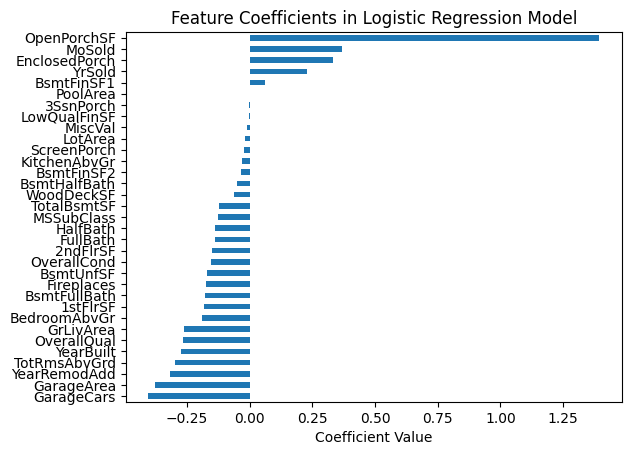

In [29]:
# Correlation analysis on training set parameter distributions
corr_columns = X_train_numerical.columns
print("corr_columns: ", corr_columns)
coefficients = pd.Series(LR.coef_[0], index=corr_columns)
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Model")
plt.xlabel("Coefficient Value")
plt.show()

Use the Logistic Regression model to perform predictions on the test dataset

In [42]:
# Load and process the test data
df_test = pd.read_csv('./data/test.csv')
df_test.shape

(1459, 80)

Note that the train/test split appears to be nearly 50/50, with train.csv having 1460 rows and test.csv having 1459 rows.

In [54]:
# limit features to those used in training
X_test = df_test[X_train_numerical.columns]
X_test.shape

(1459, 33)

In [59]:
X_test.dropna(axis="rows", inplace=True)
X_test_norm = StandardScaler().fit(X_test).transform(X_test)

# predict against test set
y_pred = LR.predict(X_test_norm)
print("y_pred: ", y_pred)
print("y_pred shape: ", y_pred.shape)

# potential_submission = pd.DataFrame({"Id": df_test["Id"], "SalePrice": y_pred})
# potential_submission.head()

C:\Users\Peter\AppData\Local\Temp\ipykernel_3040\4013771884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.dropna(axis="rows", inplace=True)


y_pred:  [120500 272000 175000 ... 149900 118000 290000]
y_pred shape:  (1456,)


In [60]:
# Evaluate the model
yhat_prob = LR.predict_proba(X_test_norm)
print("yhat_prob: ", yhat_prob)

yhat_prob:  [[1.63501744e-04 2.84160145e-04 7.14222850e-04 ... 2.67585748e-07
  2.19953876e-06 7.64193414e-07]
 [2.55629817e-12 1.19883458e-13 1.47640532e-12 ... 2.90384962e-13
  1.90717073e-13 3.77020530e-13]
 [2.71303284e-05 3.38588773e-06 3.21770072e-05 ... 8.35743918e-05
  8.93336508e-05 1.42039209e-04]
 ...
 [3.02802522e-06 7.43174763e-06 4.41532084e-07 ... 1.19683780e-04
  6.97337817e-06 1.12217038e-05]
 [6.71923191e-05 2.03330256e-04 2.49002860e-04 ... 1.32032847e-07
  6.51518748e-07 3.66027292e-06]
 [4.42154393e-06 3.20120811e-06 3.57315340e-07 ... 2.25221694e-03
  4.94936634e-04 3.69840524e-04]]


Visualize y_pred on same graph as y_train

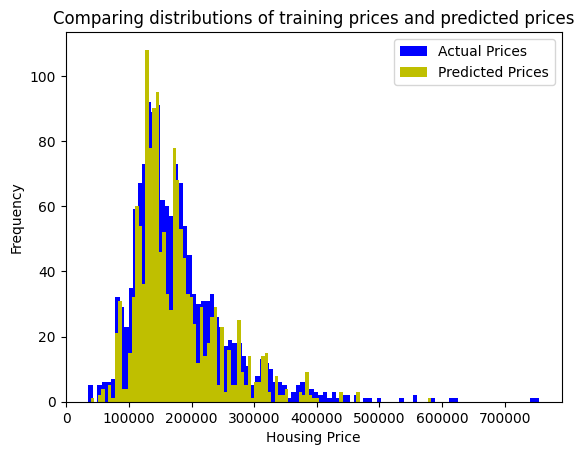

In [62]:
plt.figure()
plt.hist(y_train, bins=100, color='b', label="Actual Prices")
plt.hist(y_pred, bins=100, color='y', label="Predicted Prices")
plt.title("Comparing distributions of training prices and predicted prices")
plt.xlabel("Housing Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Nice to see that the model captured close to the distribution of the actual housing prices

## Building Advanced Regression Techniques

It's nice to see that a simple logistic regression can be quite effective at predicting housing prices. But let's not rest on our laurels. We can do better than that.

Let's try out Random Forests, using TensorFlow

In [74]:
dataset_df = pd.read_csv('./data/train.csv')

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Count'>

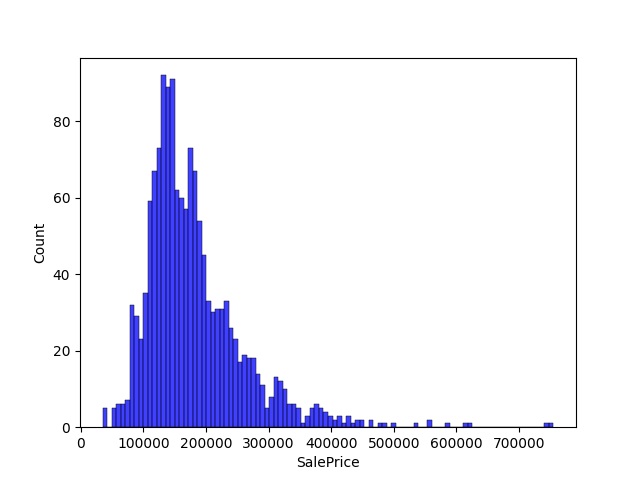

In [75]:
print(dataset_df['SalePrice'].describe())
plt.figure()
sns.histplot(dataset_df['SalePrice'], color='b', bins=100)

In [76]:
list(set(dataset_df.dtypes.tolist()))

[dtype('float64'), dtype('O'), dtype('int64')]

In [ ]:
# Separate the numerical values from the categorical
dataset_df_numer = dataset_df.select_dtypes(include=[np.number])
list(set(dataset_df_numer.dtypes.tolist()))

[dtype('float64'), dtype('int64')]

In [ ]:
train_ds_pd, valid_ds_pd = train_test_split(dataset_df_numer, test_size=0.3, random_state=58)
print(f"{len(train_ds_pd)} examples in training, {len(valid_ds_pd)} examples in testing.")

1022 examples in training, 438 examples in testing.


In [79]:
y_train_ds_pd = train_ds_pd['SalePrice']
X_train_ds_pd = train_ds_pd.drop(columns=['Id', 'SalePrice'])
y_valid_ds_pd = valid_ds_pd['SalePrice']
X_valid_ds_pd = valid_ds_pd.drop(columns=['Id', 'SalePrice'])

In [80]:
rf_reg = RandomForestRegressor(n_estimators=100,
                               max_depth=15,
                               criterion='squared_error',
                               random_state=58)
rf_reg.fit(X_train_ds_pd, y_train_ds_pd)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
y_pred = rf_reg.predict(X_valid_ds_pd)

rmse_log_score = root_mean_squared_log_error(y_valid_ds_pd, y_pred)
print('RMSE Log score : {0:.3f}'.format(rmse_log_score))

r2_rf_score = r2_score(y_valid_ds_pd, y_pred)
print('R^2 score : {0:.3f}'.format(r2_rf_score))

RMSE Log score : 0.159
R^2 score : 0.864


Try increasing the `max_depth`...

In [84]:
rf_reg = RandomForestRegressor(n_estimators=100,
                               max_depth=35,
                               criterion='squared_error',
                               random_state=58)
rf_reg.fit(X_train_ds_pd, y_train_ds_pd)

y_pred = rf_reg.predict(X_valid_ds_pd)

rmse_log_score = root_mean_squared_log_error(y_valid_ds_pd, y_pred)
print('RMSE Log score : {0:.3f}'.format(rmse_log_score))

r2_rf_score = r2_score(y_valid_ds_pd, y_pred)
print('R^2 score : {0:.3f}'.format(r2_rf_score))

RMSE Log score : 0.158
R^2 score : 0.867


Try increasing the `n_estimators`

In [85]:
rf_reg = RandomForestRegressor(n_estimators=200,
                               max_depth=15,
                               criterion='squared_error',
                               random_state=58)
rf_reg.fit(X_train_ds_pd, y_train_ds_pd)

y_pred = rf_reg.predict(X_valid_ds_pd)

rmse_log_score = root_mean_squared_log_error(y_valid_ds_pd, y_pred)
print('RMSE Log score : {0:.3f}'.format(rmse_log_score))

r2_rf_score = r2_score(y_valid_ds_pd, y_pred)
print('R^2 score : {0:.3f}'.format(r2_rf_score))

RMSE Log score : 0.159
R^2 score : 0.869


### Try One-Hot Encoding
Try encoding categorical columns using one-hot encoding (danger: this can balloon the feature space)

In [83]:
categorical_cols = dataset_df.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(dataset_df, columns=categorical_cols)

X_encoded = df_encoded.drop(columns=['Id', 'SalePrice'])
y_encoded = df_encoded[['SalePrice']]

X_enc_train, X_enc_valid, y_enc_train, y_enc_valid = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=58)

df_enc_rf_reg = RandomForestRegressor(n_estimators=100,
                               max_depth=15,
                               criterion='squared_error',
                               random_state=58)
df_enc_rf_reg.fit(X_enc_train, y_enc_train)

y_pred = df_enc_rf_reg.predict(X_enc_valid)

def_enc_rmse_log_score = root_mean_squared_log_error(y_enc_valid, y_pred)
print('RMSE Log score : {0:.3f}'.format(def_enc_rmse_log_score))

def_enc_r2_rf_score = r2_score(y_enc_valid, y_pred)
print('R^2 score : {0:.3f}'.format(def_enc_r2_rf_score))

c:\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RMSE Log score : 0.159
R^2 score : 0.864
